In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [7]:
df = pd.read_csv("/content/UdemyCoursesDataset.csv")

In [8]:
df.head(7)

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments
5,1122832,#6 Piano Hand Coordination: Play Open 10 Balla...,True,65,2015,3,21,Intermediate Level,44 mins,2017-03-08T17:53:36Z,Musical Instruments
6,1123184,#7 Piano Hand Coordination: Play Piano Runs in...,True,65,2015,2,25,Intermediate Level,1 hour,2017-03-08T18:09:32Z,Musical Instruments


In [9]:
df.tail()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
3677,328960,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,4 hours,2015-04-20T22:15:17Z,Web Development
3678,552700,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,5 hours,2015-10-26T20:04:21Z,Musical Instruments
3679,631754,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,6.5 hours,2015-11-11T18:55:45Z,Web Development
3680,1225194,Zoho Books Gestion Financière d'Entreprise pas...,False,Free,229,0,33,All Levels,2 hours,2017-05-26T16:45:55Z,Business Finance
3681,964478,Zombie Apocalypse Photoshop Actions,True,50,12,1,15,All Levels,1.5 hours,2016-09-26T22:19:48Z,Graphic Design


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB


In [11]:
df.describe()

,course_id,num_subscribers,num_reviews,num_lectures
count,3.682000e+03,3682.000000,3682.000000,3682.000000
mean,6.766121e+05,3194.230310,156.093156,40.065182
std,3.436355e+05,9499.378361,934.957204,50.373299
min,8.324000e+03,0.000000,0.000000,0.000000
25%,4.078430e+05,110.250000,4.000000,15.000000
50%,6.885580e+05,911.500000,18.000000,25.000000
75%,9.617515e+05,2540.250000,67.000000,45.000000
max,1.282064e+06,268923.000000,27445.000000,779.000000


In [12]:
df.isnull().sum()

,0
course_id,0
course_title,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0
published_timestamp,0


In [13]:
df.dropna(inplace=True)#to get null from data

In [14]:
df.fillna(df.mean(numeric_only=True), inplace=True)#if row = null convert to mean #median() and mode()

In [15]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
3677    False
3678    False
3679    False
3680    False
3681    False
Length: 3682, dtype: bool>

In [16]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [17]:
for x in df.index:
  if(df.loc[x, 'num_lectures']==0):
    df.drop(x,inplace=True)


In [18]:
df['course_id'].nunique()

3671

In [19]:
df.drop(columns=['course_id'],inplace=True)

In [20]:
df.shape

(3671, 10)

In [21]:
df['published_timestamp']=pd.to_datetime(df['published_timestamp'])
df['year']=df['published_timestamp'].dt.year

In [22]:
df

,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,year
0,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18 05:07:05+00:00,Musical Instruments,2014
1,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12 19:06:34+00:00,Musical Instruments,2017
2,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26 18:34:57+00:00,Musical Instruments,2017
3,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21 23:48:18+00:00,Musical Instruments,2017
4,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21 23:44:49+00:00,Musical Instruments,2017
...,...,...,...,...,...,...,...,...,...,...,...
3677,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,4 hours,2015-04-20 22:15:17+00:00,Web Development,2015
3678,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,5 hours,2015-10-26 20:04:21+00:00,Musical Instruments,2015
3679,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,6.5 hours,2015-11-11 18:55:45+00:00,Web Development,2015
3680,Zoho Books Gestion Financière d'Entreprise pas...,False,Free,229,0,33,All Levels,2 hours,2017-05-26 16:45:55+00:00,Business Finance,2017


In [23]:
df['month']=df['published_timestamp'].dt.month
df

,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,year,month
0,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18 05:07:05+00:00,Musical Instruments,2014,9
1,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12 19:06:34+00:00,Musical Instruments,2017,4
2,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26 18:34:57+00:00,Musical Instruments,2017,4
3,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21 23:48:18+00:00,Musical Instruments,2017,2
4,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21 23:44:49+00:00,Musical Instruments,2017,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3677,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,4 hours,2015-04-20 22:15:17+00:00,Web Development,2015,4
3678,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,5 hours,2015-10-26 20:04:21+00:00,Musical Instruments,2015,10
3679,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,6.5 hours,2015-11-11 18:55:45+00:00,Web Development,2015,11
3680,Zoho Books Gestion Financière d'Entreprise pas...,False,Free,229,0,33,All Levels,2 hours,2017-05-26 16:45:55+00:00,Business Finance,2017,5


<Axes: >

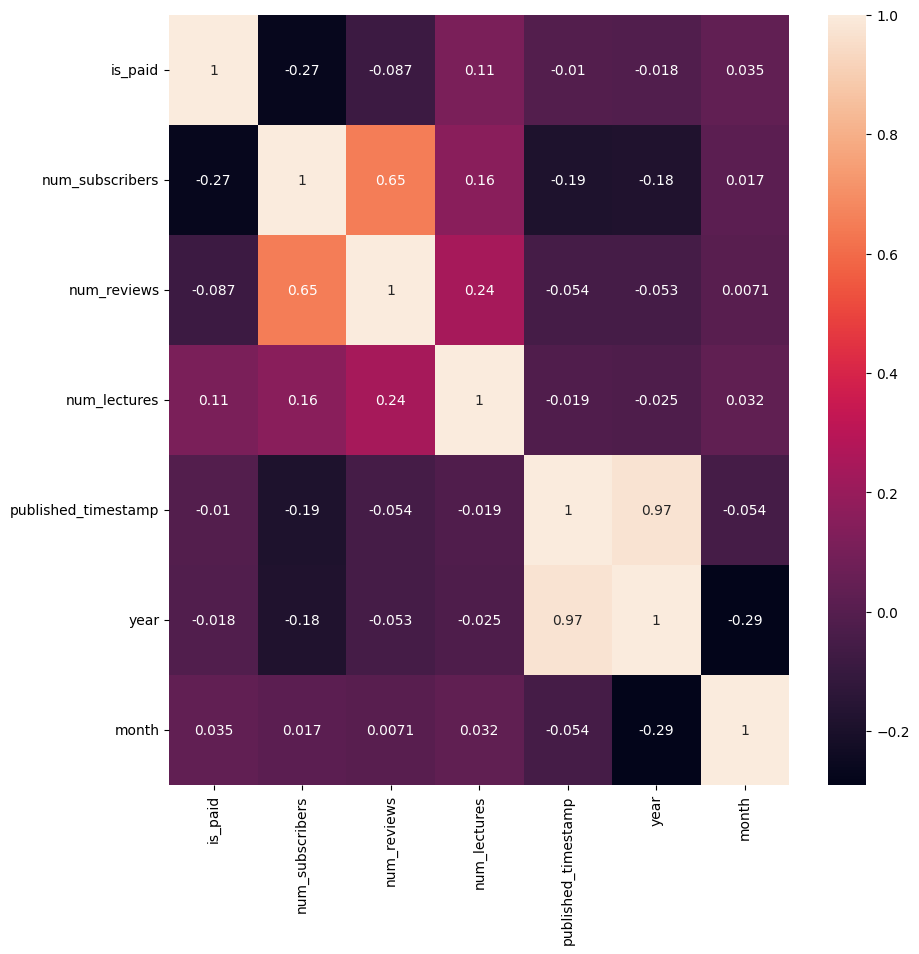

In [24]:
numerical_df=df.select_dtypes(exclude=np.object_)
plt.figure(figsize=(10,10))
sns.heatmap(numerical_df.corr(),annot=True)


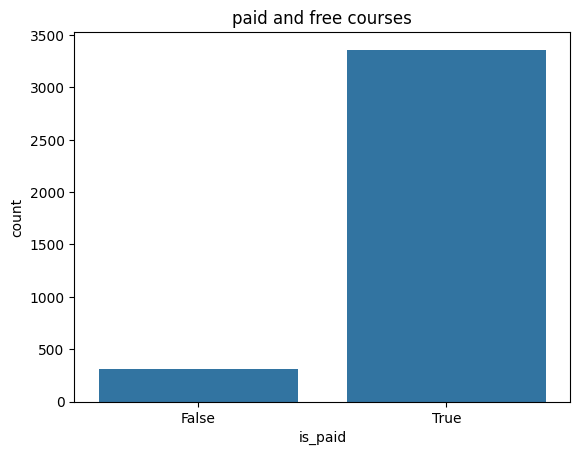

In [25]:
sns.countplot(x='is_paid',data=df)
plt.title('paid and free courses')
plt.show()

In [26]:
df['is_paid'].value_counts()

,count
is_paid,
True,3361
False,310


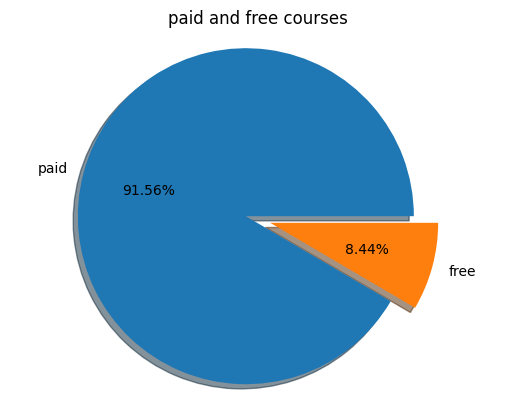

In [27]:
plt.pie(df['is_paid'].value_counts(),labels=('paid','free'),autopct='%1.2f%%',shadow=True,explode=[0,0.15])
plt.title('paid and free courses')
plt.axis('equal')
plt.show()

<Axes: title={'center': 'Average Demand (Free/Paid)'}, xlabel='is_paid', ylabel='num_subscribers'>

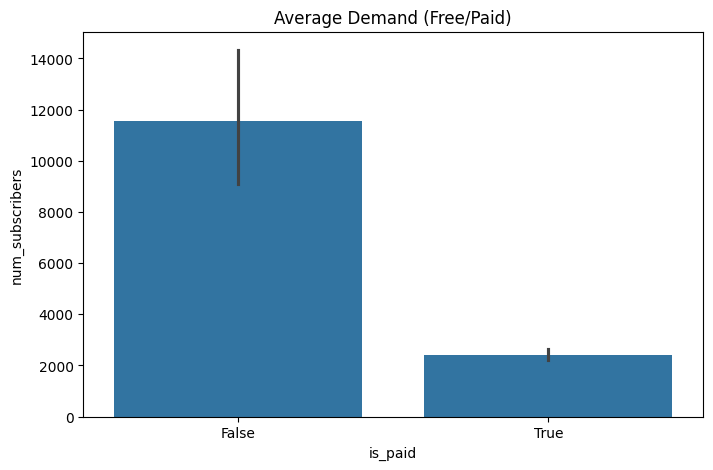

In [28]:
plt.figure(figsize=(8,5))
plt.title('Average Demand (Free/Paid)')
sns.barplot(x='is_paid',y='num_subscribers',data=df)

In [29]:
df['subject'].value_counts()

,count
subject,
Web Development,1199
Business Finance,1190
Musical Instruments,680
Graphic Design,602


<Axes: xlabel='subject', ylabel='count'>

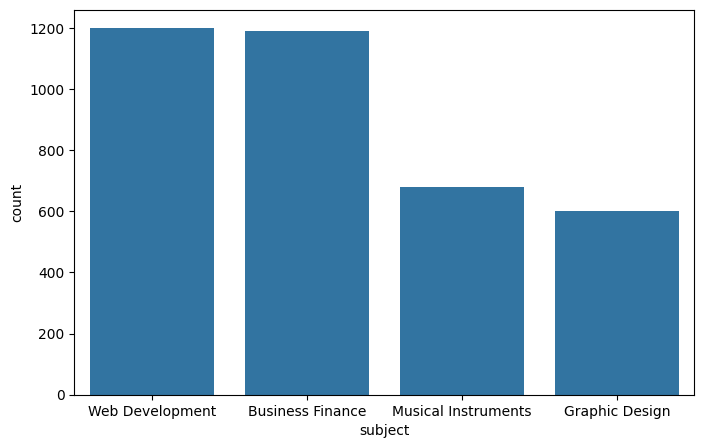

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data = df,x = 'subject',order=df.subject.value_counts().index)

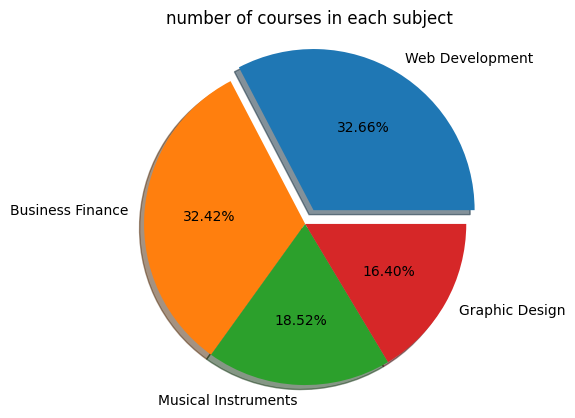

In [31]:
plt.pie(df['subject'].value_counts(),labels=df['subject'].value_counts().index,autopct='%1.2f%%',shadow=True,explode = [0.1,0,0,0])
plt.title('number of courses in each subject')
plt.axis('equal')
plt.show()

<Axes: title={'center': 'Average Demand by course Subjects'}, xlabel='subject', ylabel='num_subscribers'>

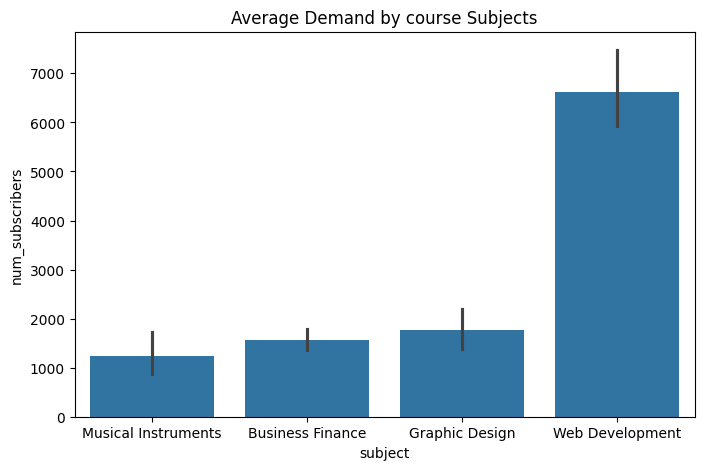

In [32]:
plt.figure(figsize=(8,5))
plt.title('Average Demand by course Subjects')
sns.barplot(x='subject',y='num_subscribers',data=df)

<Axes: title={'center': 'Average Demand by course Subjects'}, xlabel='subject', ylabel='num_subscribers'>

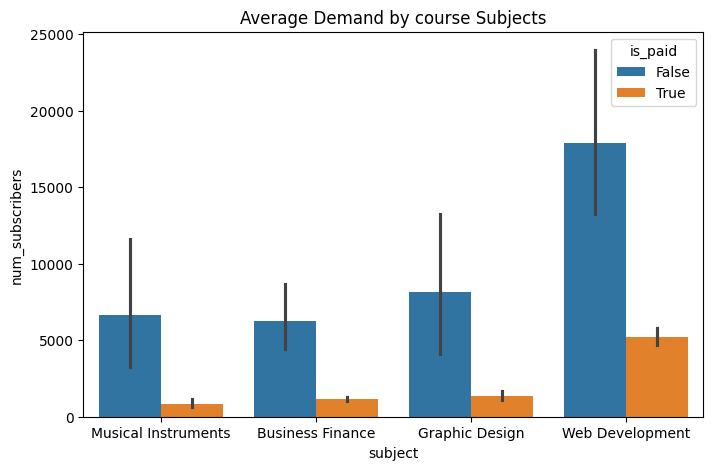

In [33]:
plt.figure(figsize=(8,5))
plt.title('Average Demand by course Subjects')
sns.barplot(x='subject',y='num_subscribers',hue='is_paid',data=df)

<Axes: xlabel='level', ylabel='count'>

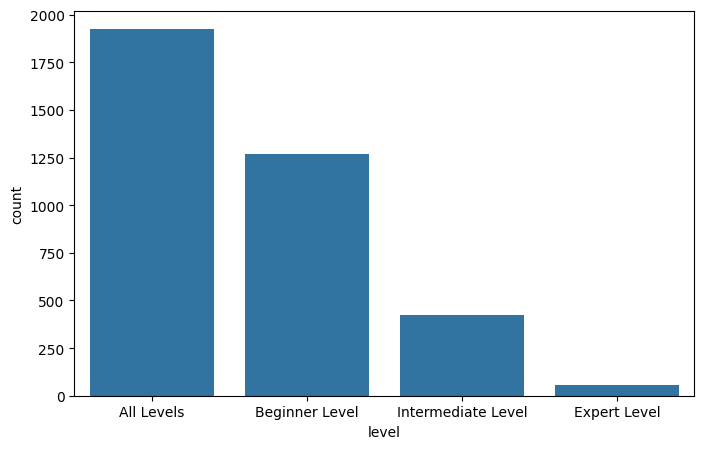

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='level',order=df.level.value_counts().index)

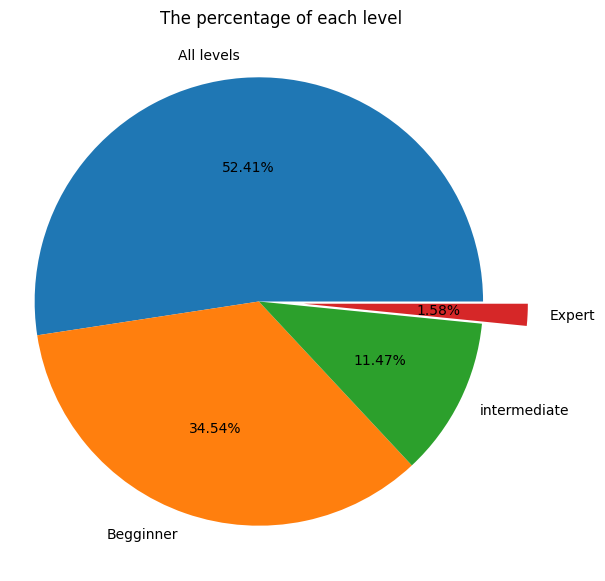

In [35]:
plt.figure(figsize=(7,7))
plt.pie(df.level.value_counts(),labels=['All levels','Begginner','intermediate','Expert'],autopct='%1.2f%%',explode=[0,0,0,0.2])
plt.title('The percentage of each level')
plt.axis('equal')
plt.show()


In [36]:
df['price'] = df['price'].replace('Free', 0)
df['price'] = pd.to_numeric(df['price'])

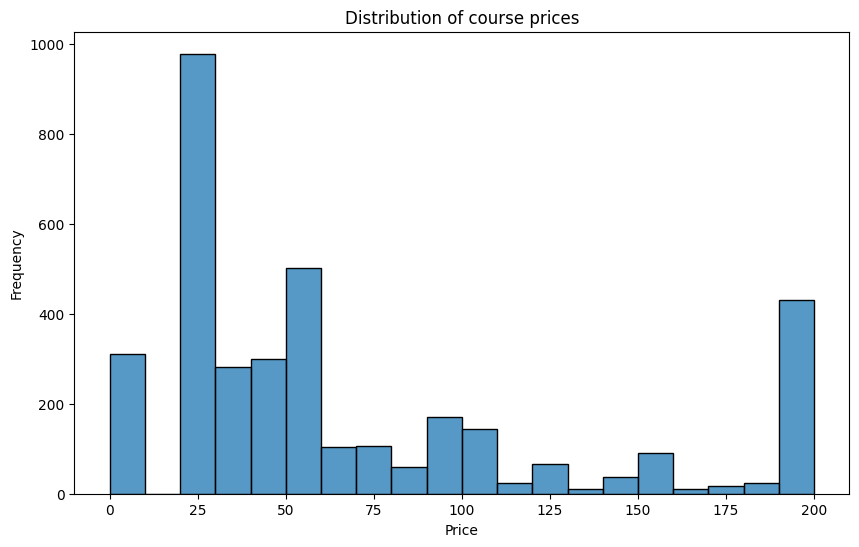

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='price',bins=20)
plt.title('Distribution of course prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


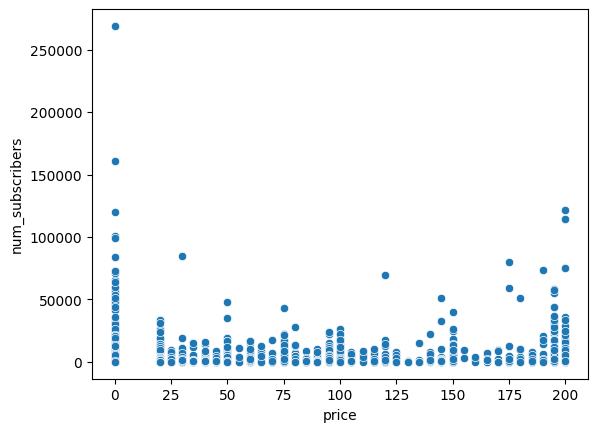

In [38]:
sns.scatterplot(x='price',y='num_subscribers',data=df)
plt.show()

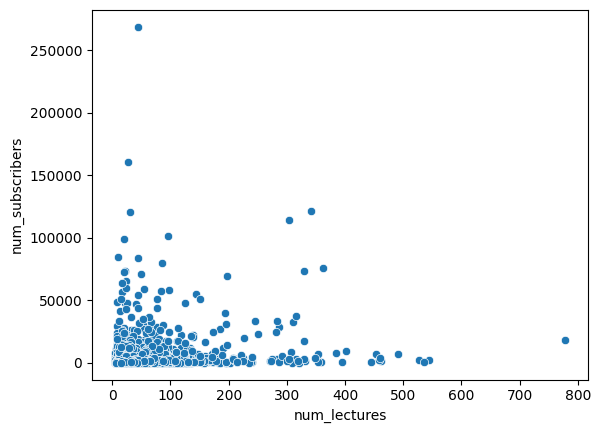

In [39]:
sns.scatterplot(x='num_lectures',y='num_subscribers',data=df)
plt.show()

In [40]:
df['content_duration'] = df['content_duration'].str.extract(r'(\d+\.?\d*)').astype(float)

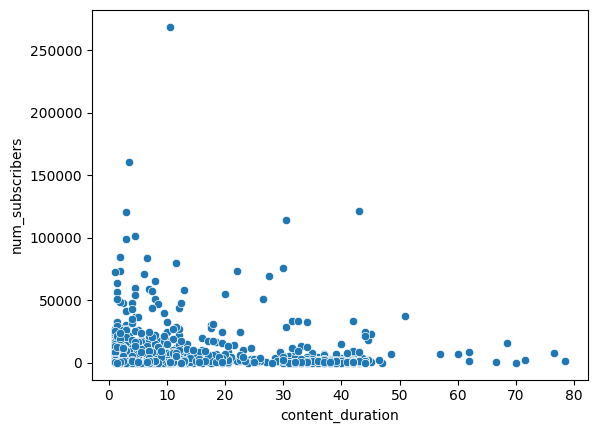

In [41]:
sns.scatterplot(x='content_duration',y='num_subscribers',data=df)
plt.show()

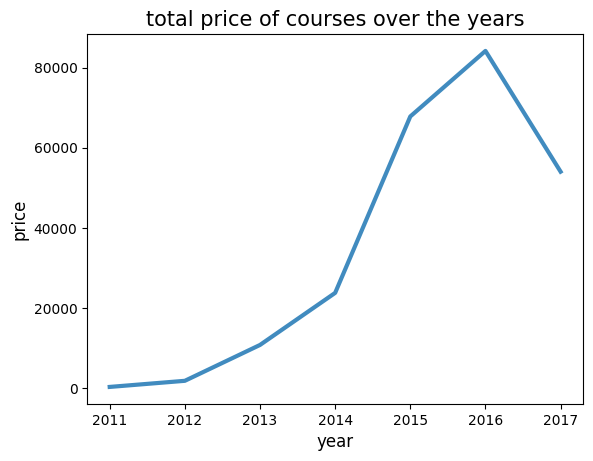

In [42]:
plt.plot(df.groupby('year')['price'].sum(),ls='-',lw=3,alpha=0.85)
plt.title('total price of courses over the years',size=15)
plt.xlabel('year',color='k',size=12)
plt.ylabel('price',color='k',size=12)
plt.show()

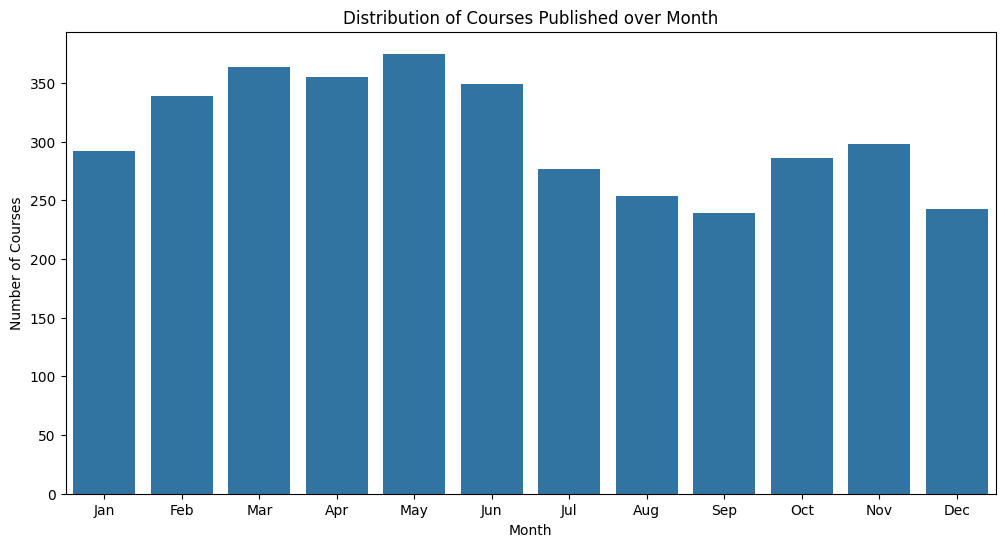

In [43]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='month')
plt.title('Distribution of Courses Published over Month')
plt.xlabel('Month')
plt.ylabel('Number of Courses')
plt.xticks(range(0,12),['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

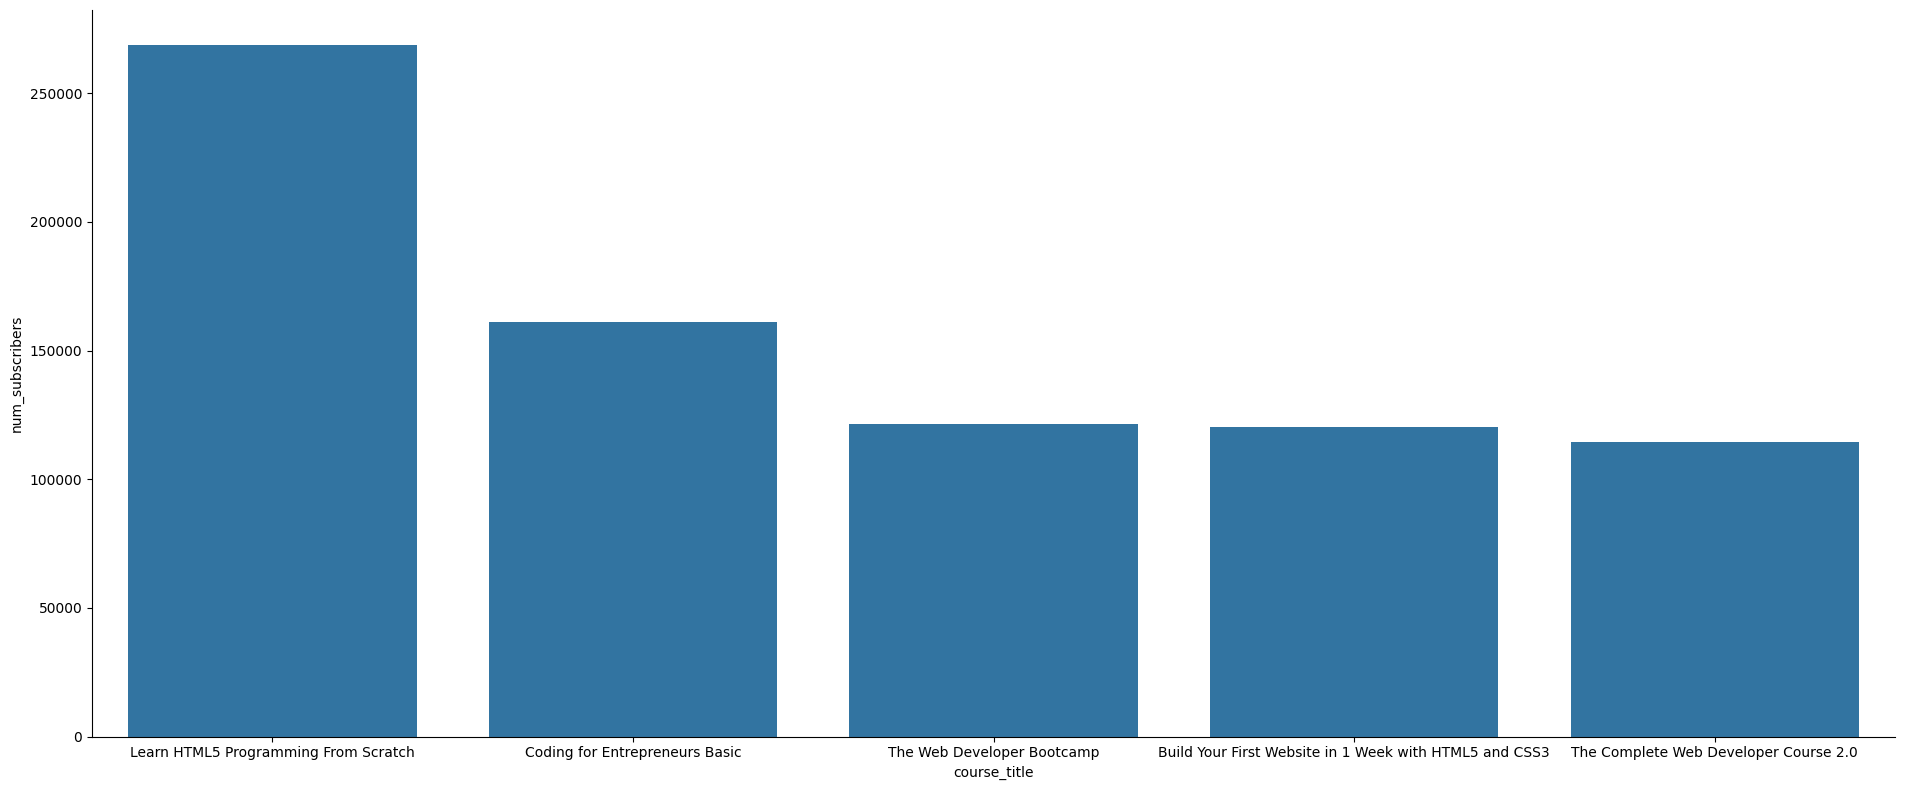

In [44]:
z=df.loc[df.num_subscribers.sort_values(ascending=False).head().index]
sns.catplot(data=z,kind='bar',height=8,aspect=2.4,x='course_title',y='num_subscribers')

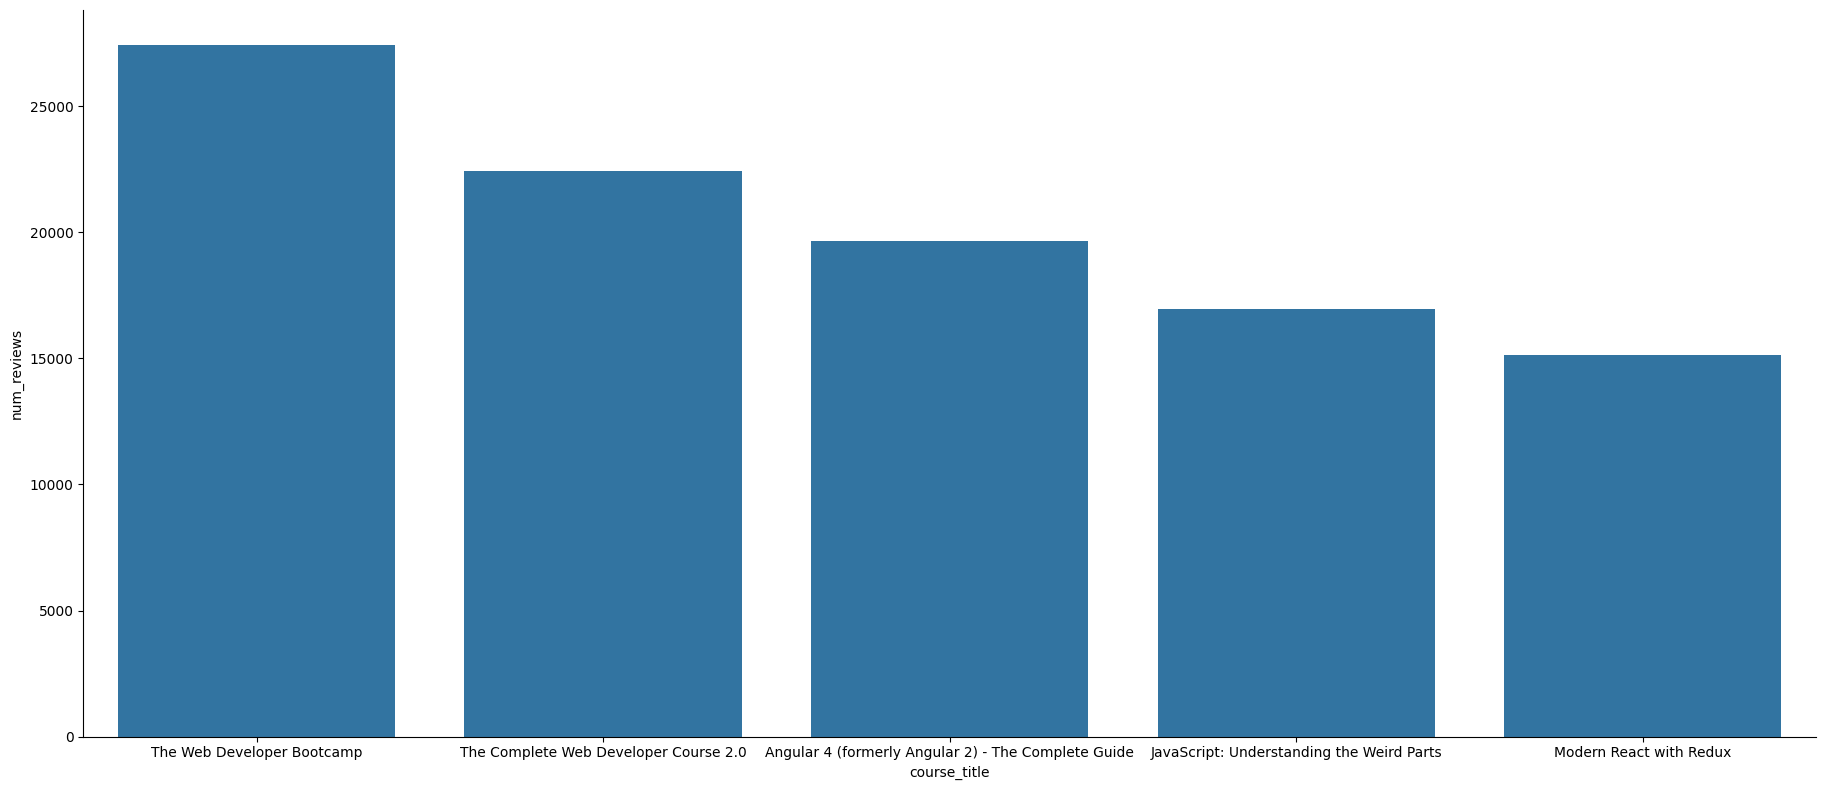

In [45]:
z=df.loc[df.num_reviews.sort_values(ascending=False).head().index]
sns.catplot(data=z,kind='bar',height=8,aspect=2.3,x='course_title',y='num_reviews')

<Axes: xlabel='price', ylabel='count'>

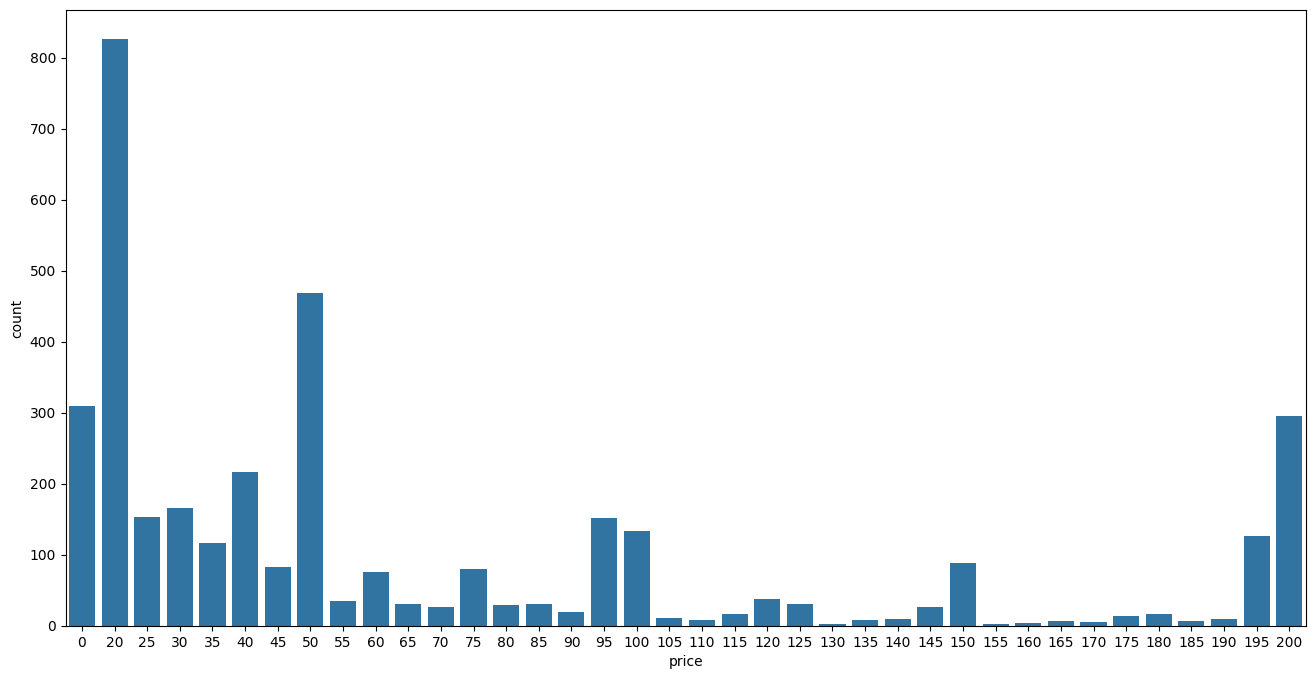

In [46]:
plt.figure(figsize=(16,8))
sns.countplot(data=df,x='price')

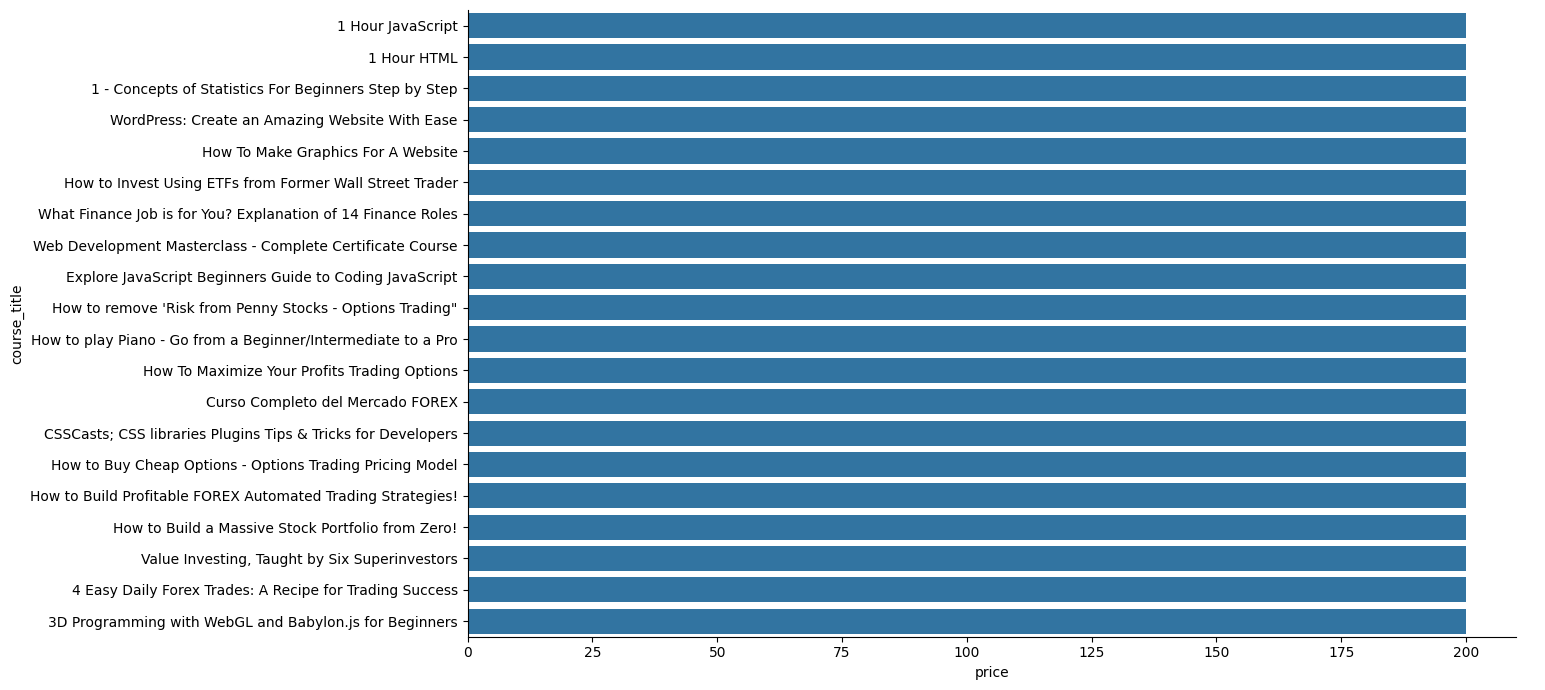

In [47]:
z=df.loc[df.price.sort_values(ascending=False).head(20).index]
sns.catplot(data=z,kind='bar',height=7,aspect=2.2,y='course_title',x='price')

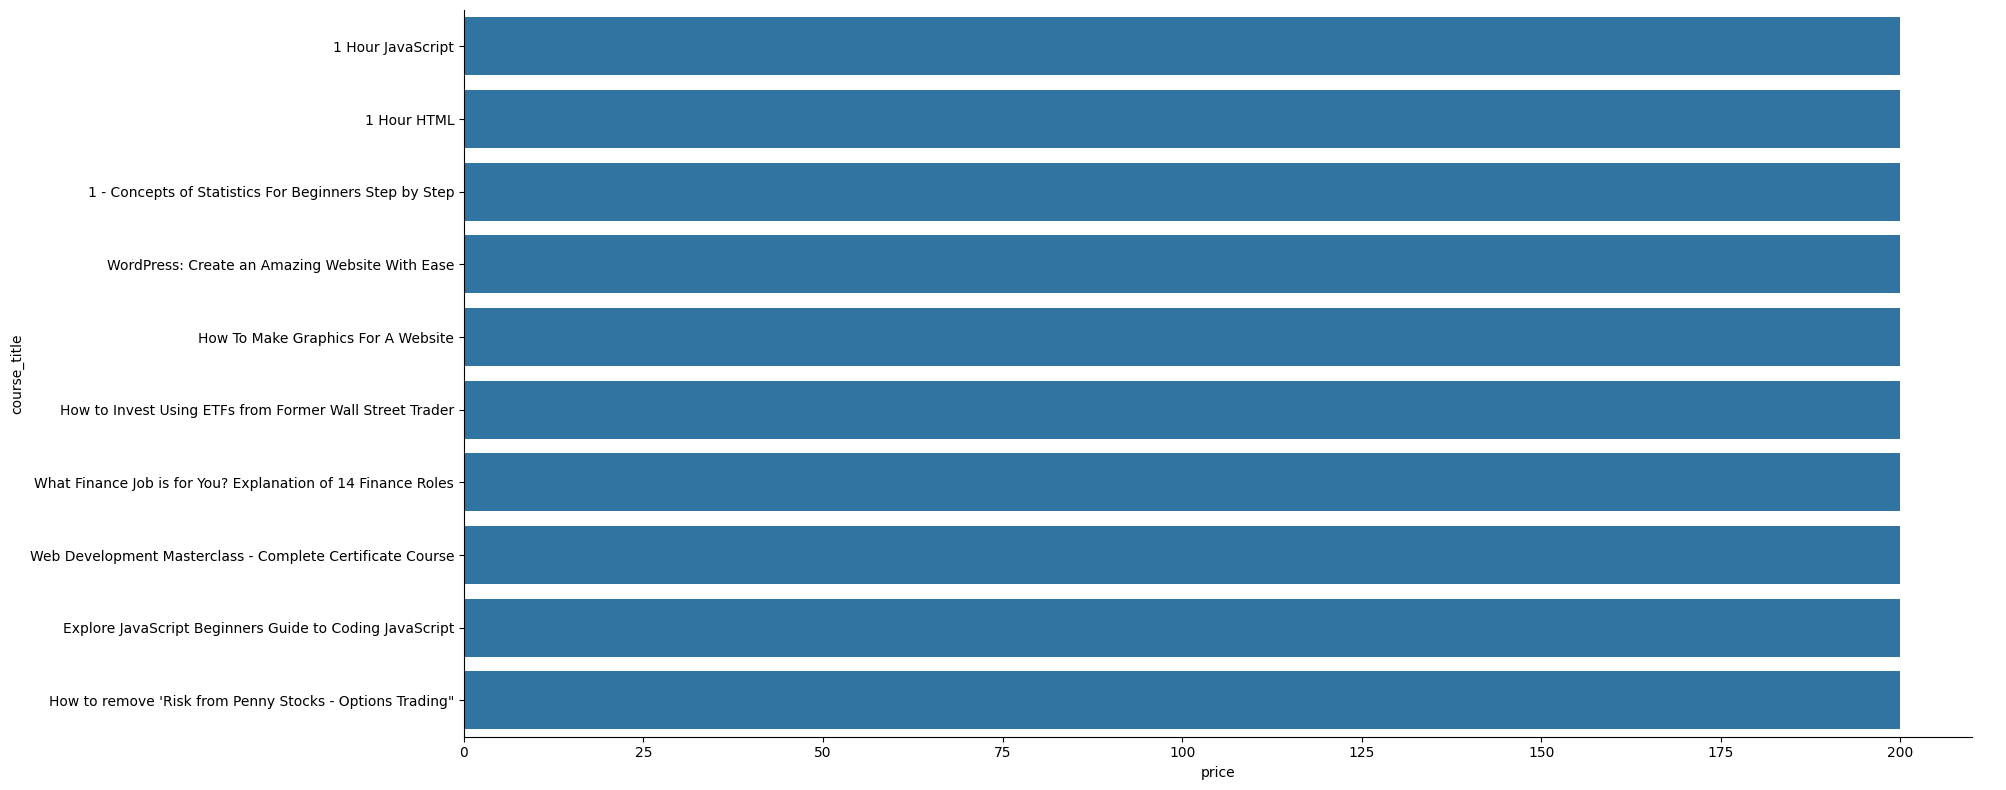

In [48]:
z=df.loc[df.price.sort_values(ascending=False).head(10).index]
sns.catplot(data=z,kind='bar',height=8,aspect=2.5,y='course_title',x='price')

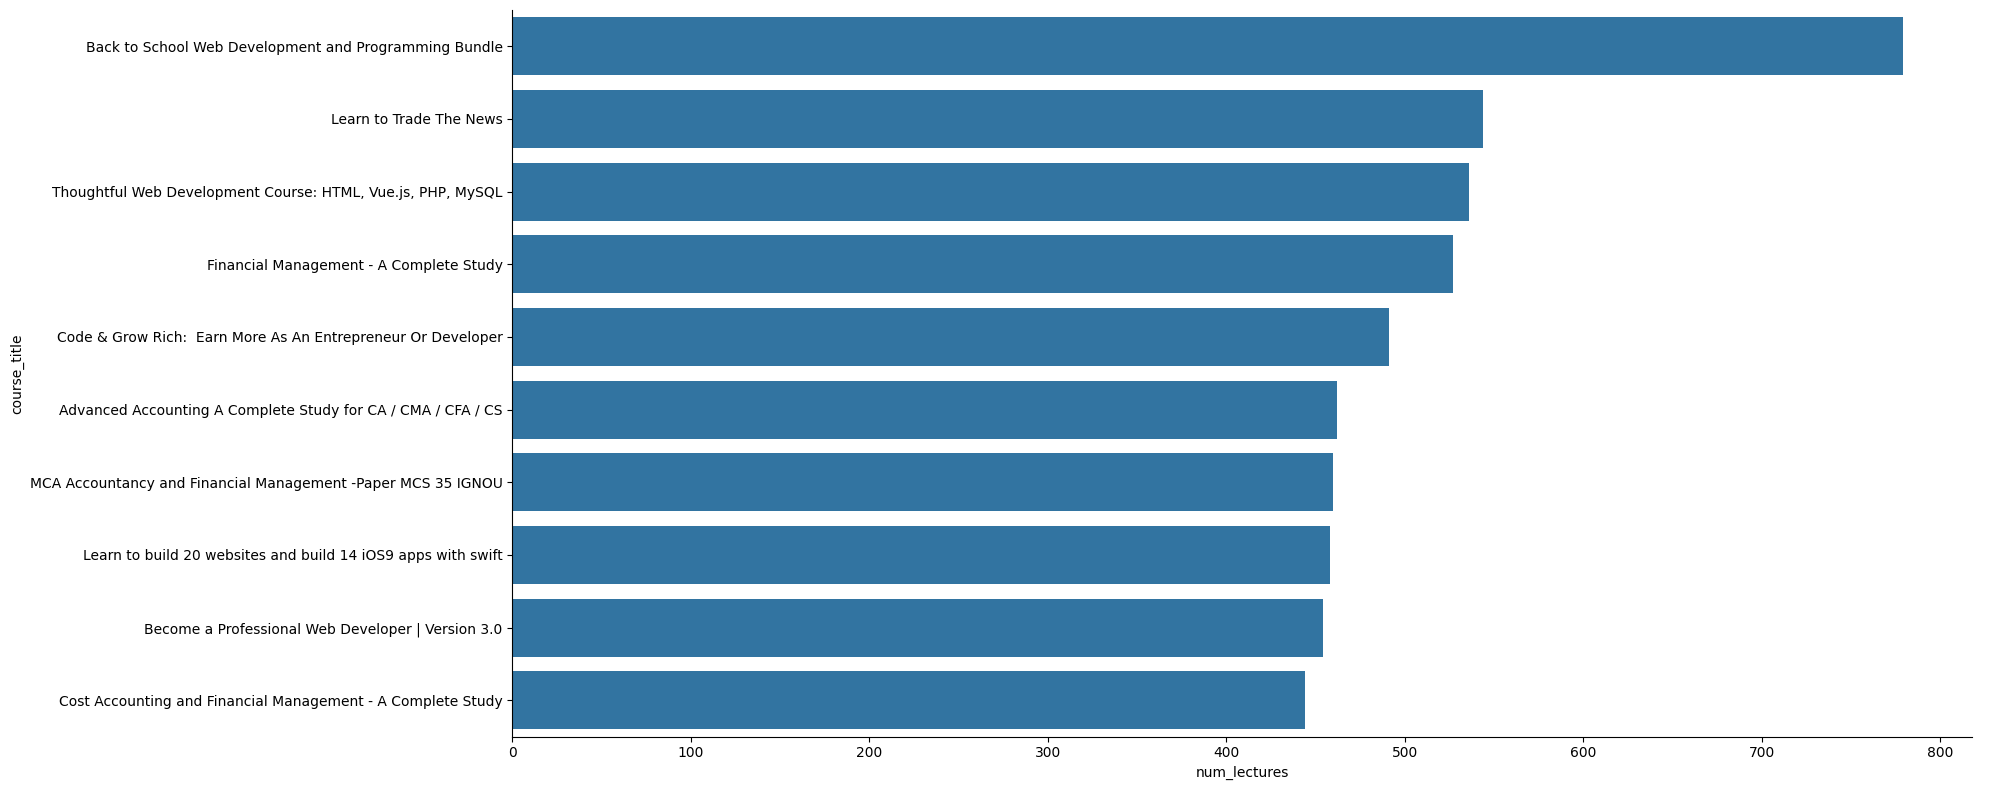

In [49]:
z=df.loc[df.num_lectures.sort_values(ascending=False).head(10).index]
sns.catplot(data=z,kind='bar',height=8,aspect=2.5,y='course_title',x='num_lectures')

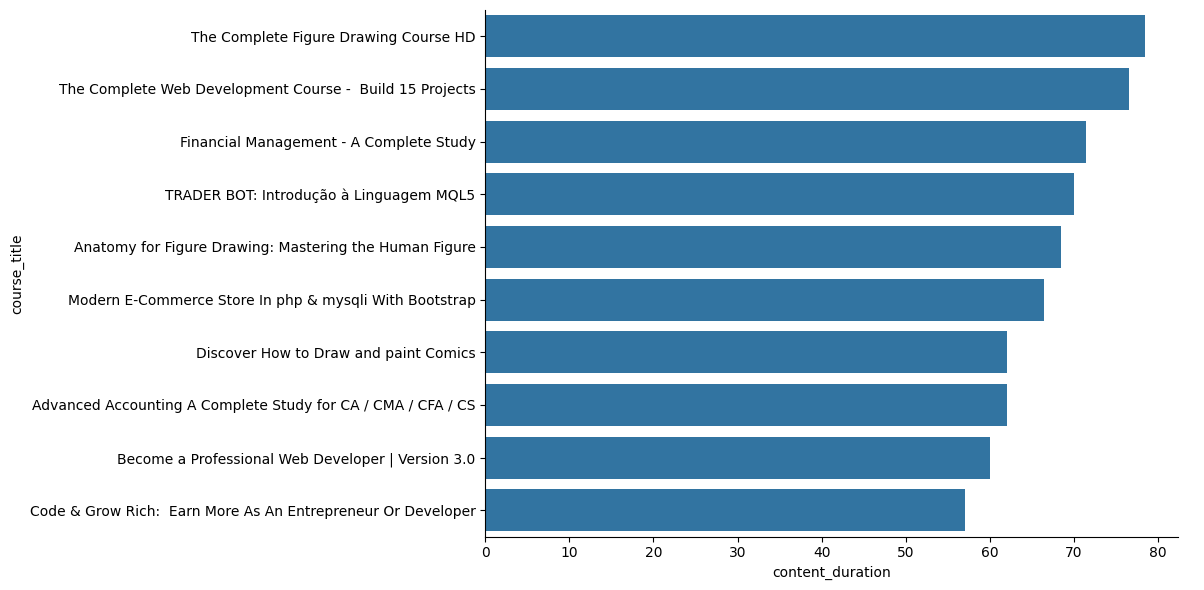

In [50]:
z=df.loc[df.content_duration.sort_values(ascending=False).head(10).index]
sns.catplot(data=z,kind='bar',height=6,aspect=2,y='course_title',x='content_duration')

/tmp/ipykernel_1260/3070777801.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_subject.index, y=revenue_by_subject.values, palette='Blues_d')


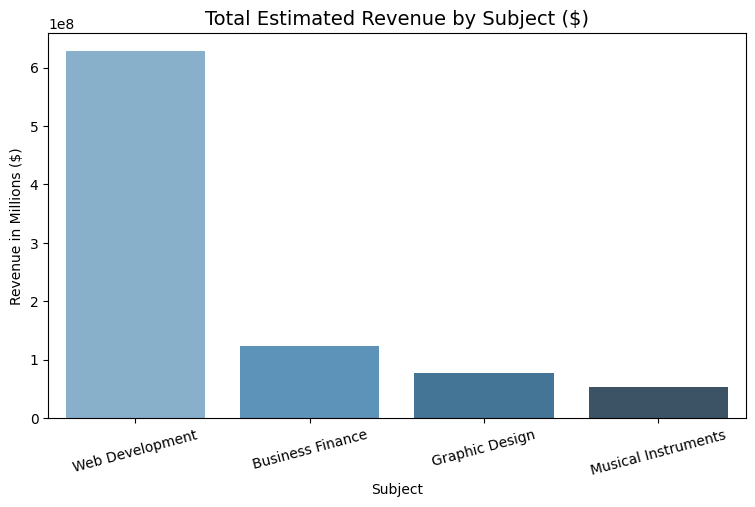

,course_title,subject,price,num_subscribers,estimated_revenue
3385,The Web Developer Bootcamp,Web Development,200,121584,24316800
3316,The Complete Web Developer Course 2.0,Web Development,200,114512,22902400
2829,Pianoforall - Incredible New Way To Learn Pian...,Musical Instruments,200,75499,15099800
285,Angular 4 (formerly Angular 2) - The Complete ...,Web Development,190,73783,14018770
2034,JavaScript: Understanding the Weird Parts,Web Development,175,79612,13932100


In [51]:
df['estimated_revenue'] = df['price'] * df['num_subscribers']
plt.figure(figsize=(9, 5))
revenue_by_subject = df.groupby('subject')['estimated_revenue'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_subject.index, y=revenue_by_subject.values, palette='Blues_d')
plt.title('Total Estimated Revenue by Subject ($)', fontsize=14)
plt.xlabel('Subject')
plt.ylabel('Revenue in Millions ($)')
plt.xticks(rotation=15)
plt.show()
top_earning = df.nlargest(5, 'estimated_revenue')[['course_title', 'subject', 'price', 'num_subscribers', 'estimated_revenue']]
top_earning

/tmp/ipykernel_1260/155383819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_paid', y='engagement_rate', data=df, palette='Set2')


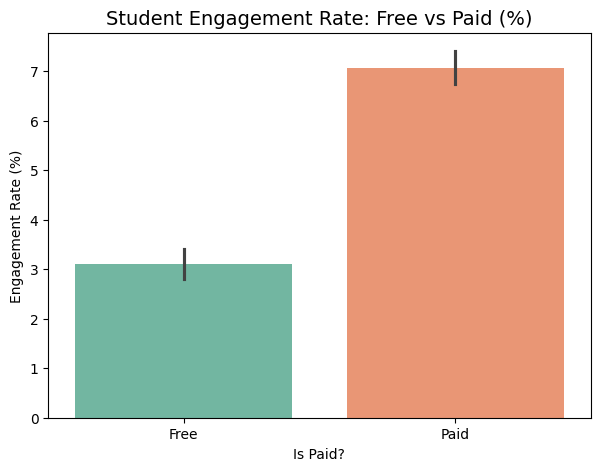

In [52]:
df['engagement_rate'] = np.where(df['num_subscribers'] > 0, (df['num_reviews'] / df['num_subscribers']) * 100, 0)
plt.figure(figsize=(7, 5))
sns.barplot(x='is_paid', y='engagement_rate', data=df, palette='Set2')
plt.title('Student Engagement Rate: Free vs Paid (%)', fontsize=14)
plt.xlabel('Is Paid?')
plt.ylabel('Engagement Rate (%)')
plt.xticks([0, 1], ['Free', 'Paid'])
plt.show()

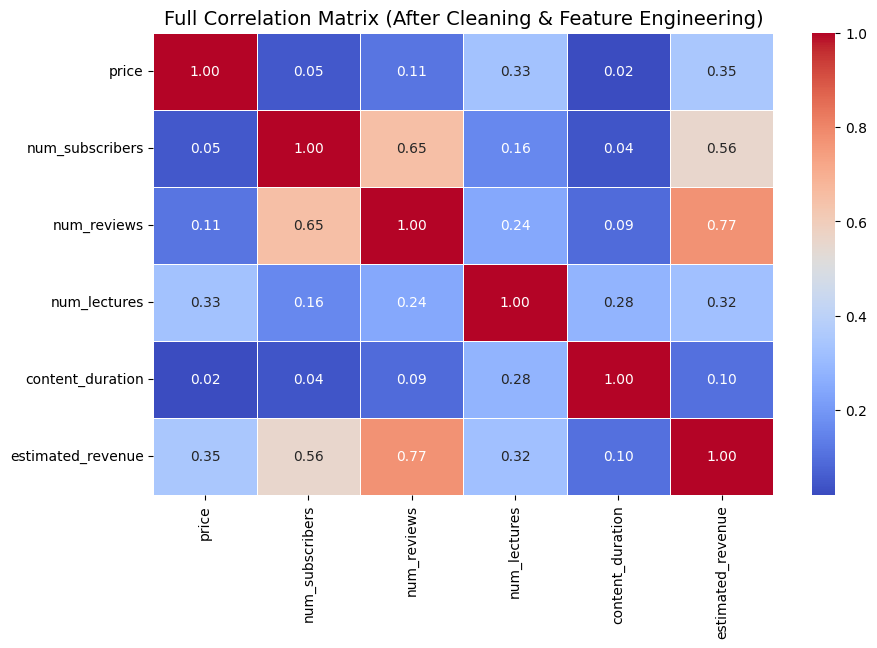

In [53]:
plt.figure(figsize=(10, 6))
numeric_cols = ['price', 'num_subscribers', 'num_reviews', 'num_lectures', 'content_duration', 'estimated_revenue']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Full Correlation Matrix (After Cleaning & Feature Engineering)', fontsize=14)
plt.show()